
Để hiểu được sự vận hành phức tạp của các mạng nơ-ron học sâu (Deep Learning) hiện đại, chúng ta bắt buộc phải quay về với viên gạch nền móng đầu tiên: **Perceptron**. Báo cáo này sẽ bóc tách bản chất toán học của Perceptron, cách thuật toán này "học", những giới hạn chí mạng khiến nó từng bị hắt hủi, và con đường tiến hóa tất yếu lên mạng Multi-Layer Perceptron (MLP).

---

## 1. Thế nào là Perceptron?

Perceptron (đề xuất bởi Frank Rosenblatt năm 1958) là mô hình nơ-ron nhân tạo sơ khai nhất. Xét về bản chất toán học, nó là một thuật toán **phân loại nhị phân tuyến tính** (Linear Binary Classifier). Nhiệm vụ của nó là vạch ra một đường thẳng (hoặc siêu mặt phẳng trong không gian đa chiều) để chia tách dữ liệu thành 2 nhóm riêng biệt.

Cấu trúc của một Perceptron bao gồm 4 thành phần cốt lõi:
*   **Đầu vào (Inputs - $x_i$):** Các đặc trưng của dữ liệu.
*   **Trọng số (Weights - $w_i$):** Mức độ quan trọng của từng đầu vào.
*   **Độ lệch (Bias - $b$):** Ngưỡng dịch chuyển giúp mô hình linh hoạt.
*   **Hàm kích hoạt (Activation Function):** Perceptron cổ điển sử dụng **Hàm Bước Heaviside (Step Function)**, đưa ra quyết định cứng (1 hoặc 0 / -1).

**Cơ chế hoạt động:**
Đầu tiên, mô hình tính tổng có trọng số của các đầu vào:
$$z = \sum_{i=1}^{n} w_i x_i + b$$
Sau đó, giá trị $z$ được đưa qua Hàm Bước để đưa ra kết quả phân loại cuối cùng ($\hat{y}$):
*   $\hat{y} = 1$ nếu $z \ge 0$
*   $\hat{y} = -1$ (hoặc 0) nếu $z < 0$

---
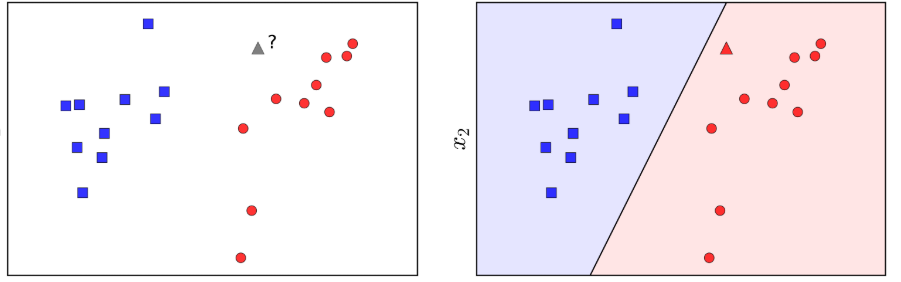

## 2. Thuật toán học của Perceptron (Perceptron Learning Algorithm - PLA)

Trái với các mô hình Machine Learning hiện đại sử dụng đạo hàm để tìm điểm tối ưu, Perceptron "học" thông qua một **luật cập nhật sửa lỗi (Error-correction learning rule)** mang tính thử và sai. Bản chất của thuật toán này là sự biến tấu của Stochastic Gradient Descent (SGD) áp dụng trên một hàm mất mát đặc thù nhằm lách qua sự cản trở của Hàm Bước.

**Quy trình cập nhật trọng số:**
Thuật toán duyệt qua từng điểm dữ liệu $(x_i, y_i)$. Nếu mô hình phân loại đúng ($\hat{y}_i = y_i$), trọng số được giữ nguyên. Nếu mô hình phân loại sai, trọng số $w$ và bias $b$ sẽ được cập nhật theo công thức:
$$w = w + \eta(y_i - \hat{y}_i)x_i$$
$$b = b + \eta(y_i - \hat{y}_i)$$
*(Trong đó $\eta$ là hệ số học - learning rate).*

**Ý nghĩa hình học:** 
Việc cộng hoặc trừ vector dữ liệu $x_i$ vào vector trọng số $w$ thực chất là hành động **xoay đường ranh giới** về phía điểm dữ liệu bị phân loại sai, lùa nó về đúng nhóm. Thuật toán sẽ dừng lại ngay lập tức khi toàn bộ tập huấn luyện được phân loại chính xác 100%.

---

## 3. Những hạn chế chí mạng của Perceptron

Sự sụp đổ của mô hình Perceptron cổ điển (dẫn đến Mùa đông AI - AI Winter) bắt nguồn từ 3 giới hạn nền tảng:

### 3.1. Sự bất lực trước dữ liệu phi tuyến
Vì sử dụng phương trình bậc nhất $z = w^Tx + b$, ranh giới quyết định của Perceptron vĩnh viễn là một đường thẳng (hoặc mặt phẳng). Năm 1969, Minsky và Papert chứng minh rằng Perceptron **không thể giải quyết được bài toán cổng XOR**, do dữ liệu của hàm này nằm chéo nhau và không thể chia tách tuyến tính (Linearly Separable).
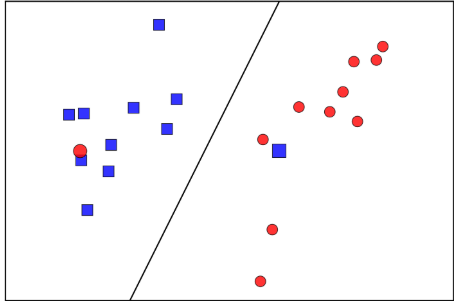
### 3.2. Không thể tối ưu hóa bằng đạo hàm (Rào cản từ Hàm Bước)
Hàm Bước có đồ thị nằm ngang, dẫn đến **đạo hàm bằng 0 ở mọi nơi**. Điều này khiến thuật toán tối ưu Gradient Descent bị tê liệt. Không có đạo hàm (Gradient), mạng nơ-ron giống như người mù đi trong đêm, không biết phải điều chỉnh trọng số theo hướng nào để làm giảm sai số một cách có hệ thống.

### 3.3. Có vô số nghiệm (nghiệm không tối ưu)
Luật cập nhật PLA sẽ dừng lại ngay khi tìm được **một đường thẳng bất kỳ** chia tách được dữ liệu. Nó không hề quan tâm đường ranh giới đó có nằm sát rạt vào dữ liệu hay không. Khác với Support Vector Machine (SVM) luôn tối ưu hóa để tìm ra lề (Margin) an toàn nhất, Perceptron cực kỳ dễ bị Overfitting và khái quát hóa kém trên dữ liệu mới.

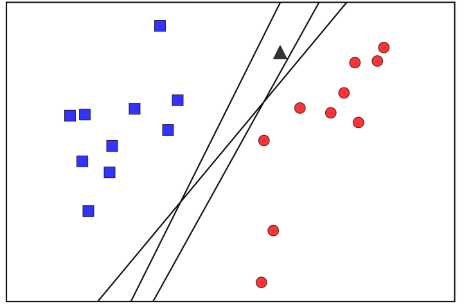


## 4. Sự tiến hóa tất yếu: Multi-Layer Perceptron (MLP)

Để phá vỡ những giới hạn trên và đưa AI tiến vào kỷ nguyên Deep Learning, mạng Multi-Layer Perceptron (MLP) đã ra đời dựa trên hai cải tiến mang tính bản lề:

### 4.1. Giải quyết bài toán phi tuyến bằng Lớp Ẩn (Hidden Layers)
Thay vì sử dụng một nơ-ron duy nhất, MLP xếp chồng hàng chục, hàng trăm nơ-ron thành các Lớp Ẩn nằm giữa Input và Output. Việc kết hợp nhiều đường thẳng lại với nhau giúp mô hình vặn xoắn không gian dữ liệu, từ đó có thể tạo ra các vùng quyết định đa giác, đường cong phức tạp để giải quyết triệt để bài toán XOR.

### 4.2. Từ bỏ Hàm Bước, khai sinh Backpropagation
Việc xếp chồng nhiều lớp sẽ vô nghĩa nếu các lớp ẩn không thể tự sửa sai. Để tính toán được sự đóng góp vào lỗi của từng nơ-ron nằm sâu bên trong mạng, các nhà khoa học đã:
1.  **Loại bỏ Hàm Bước:** Thay thế bằng các hàm kích hoạt phi tuyến có đạo hàm mượt mà như **Sigmoid, Tanh, hay ReLU**.
2.  **Áp dụng Lan truyền ngược (Backpropagation):** Dựa trên quy tắc chuỗi (Chain Rule) của giải tích, Backpropagation truyền đạo hàm từ lớp lỗi cuối cùng ngược về các lớp đầu tiên. Kết hợp với thuật toán **Gradient Descent**, toàn bộ trọng số trong mạng MLP khổng lồ được tối ưu hóa một cách đồng bộ và chính xác.

## Kết luận
Perceptron tuy thô sơ, lười biếng và tồn tại nhiều lỗ hổng toán học, nhưng lại là hạt giống vĩ đại nhất. Việc hiểu rõ những điểm yếu của nó (Hàm bước, Không gian tuyến tính, Thiếu khả năng tối ưu toàn cục) chính là chìa khóa để chúng ta làm chủ các kiến trúc Deep Learning hiện đại và các thuật toán tối ưu hàm mất mát phức tạp ngày nay.



## 5. Multi-Layer Networks (Mạng đa lớp)

Mạng nơ-ron đa lớp (Multi-Layer Perceptron - MLP), hay mạng kết nối đầy đủ (Fully Connected Network), là kiến trúc nền tảng của Học sâu (Deep Learning) nhằm giải quyết các bài toán phi tuyến tính phức tạp.

### 5.1. Cấu trúc mạng đa lớp
Một mạng đa lớp tiêu chuẩn được cấu thành từ ba thành phần chính:
*   **Lớp đầu vào (Input Layer):** Chứa các nút đại diện cho các "đặc trưng thô" (raw features) của dữ liệu (ví dụ: các điểm ảnh, thông số đo lường). Tại đây không có phép toán nào diễn ra.
*   **Các lớp ẩn (Hidden Layers):** Nằm giữa đầu vào và đầu ra. Các lớp ẩn đóng vai trò là một cỗ máy **tự động trích xuất đặc trưng (Feature Extractor)** theo dạng phân cấp. Dữ liệu đi qua ma trận trọng số và hàm kích hoạt phi tuyến (như ReLU, Sigmoid) để tạo ra các không gian vector biểu diễn đặc trưng bậc cao.
*   **Lớp đầu ra (Output Layer):** Tổng hợp các đặc trưng từ lớp ẩn cuối cùng để đưa ra dự đoán. Việc sử dụng hàm kích hoạt phụ thuộc vào miền giá trị bài toán (ví dụ: dùng hàm Tuyến tính cho giá trị thực tự do $\mathbb{R}$, hoặc dùng ReLU/Softplus để ép dự đoán $\ge 0$).
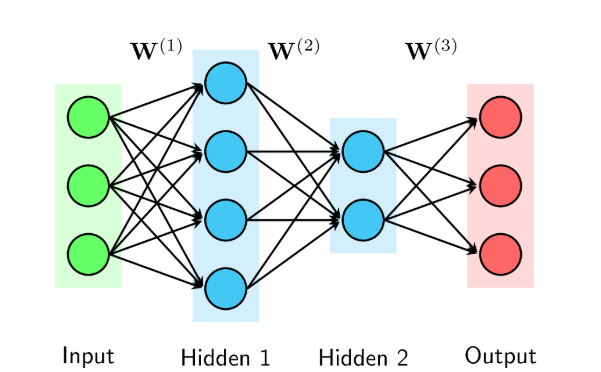
### 5.2. Quá trình Lan truyền xuôi (Forward Propagation)
Lan truyền xuôi là luồng dữ liệu chảy một chiều từ lớp đầu vào qua các lớp ẩn để sinh ra kết quả cuối cùng:

1.  Tại lớp thứ $l$, mạng nhận trạng thái ẩn từ lớp trước đó (hoặc dữ liệu $x$ nếu là lớp đầu tiên).
2.  Tính tổng tuyến tính (nhân ma trận trọng số và cộng độ lệch): 
    $$z^{(l)} = W^{(l)}h^{(l-1)} + b^{(l)}$$
3.  Áp dụng hàm kích hoạt phi tuyến đồng loạt lên toàn bộ ma trận: 
    $$h^{(l)} = \phi(z^{(l)})$$
4.  Quá trình tiếp diễn cho đến khi trả về dự đoán $\hat{y}$ ở lớp đầu ra.

---
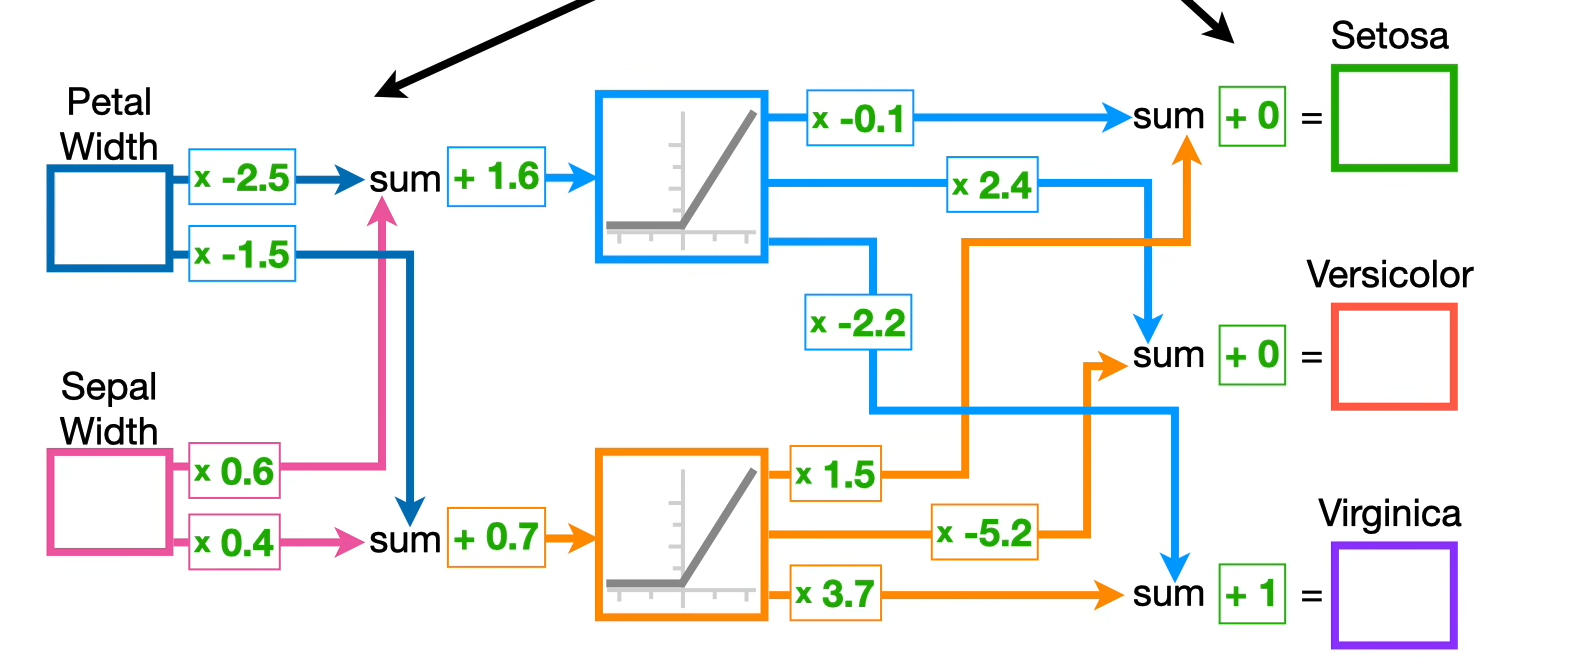

## 6. Đồ thị tính toán (Computational Graph)

Để tự động tính toán đạo hàm, quá trình lan truyền xuôi được số hóa thành một **Đồ thị có hướng không chu trình (DAG)**.

*   **Sự phân tách:** Đồ thị tách bạch rõ ràng giữa **Biến số** (chứa dữ liệu như tensor, ma trận trọng số $W$) và **Toán tử** (như phép nhân $\times$, phép cộng $+$, hàm $\phi$).
*   **Mục đích:** Việc chia nhỏ một hàm toán học phức tạp thành các phép toán vi phân cơ bản giúp máy tính dễ dàng áp dụng công thức đạo hàm cục bộ cho từng toán tử riêng biệt khi truyền ngược tín hiệu.
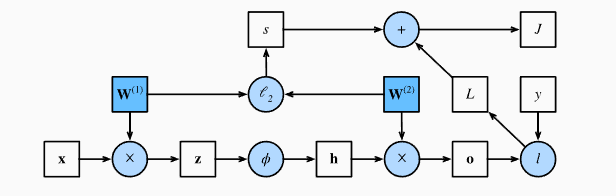
---

## 7. Backpropagation (Lan truyền ngược) và Quy tắc chuỗi (Chain Rule)

### 7.1. Thế nào là Lan truyền ngược?
Sau khi tính được Hàm mất mát (Loss - $L$) từ sai số giữa dự đoán $\hat{y}$ và nhãn thực tế $y$, Backpropagation sẽ truy ngược đồ thị tính toán từ điểm cuối về điểm đầu. Mục tiêu là tính đạo hàm (Gradient) của $L$ theo từng trọng số $w$ và độ lệch $b$ để cập nhật chúng thông qua **Gradient Descent**:
$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

### 7.2. Quy tắc Chain Rule
Backpropagation hoạt động dựa vào **Quy tắc chuỗi (Chain Rule)** của giải tích. Thay vì giải một phương trình đạo hàm khổng lồ, Chain Rule cho phép tính đạo hàm của hàm mất mát đối với một trọng số ở sâu bên trong bằng cách **nhân dồn các đạo hàm cục bộ** trên dọc đường đi.

### 7.3. Ví dụ chi tiết sử dụng Chain Rule tính đạo hàm
Xét đường dẫn tính toán qua 1 nơ-ron đơn giản:
*   Tổng tuyến tính: 
    $$z = w \cdot x + b$$
*   Hàm kích hoạt Sigmoid: 
    $$a = \sigma(z) = \frac{1}{1 + e^{-z}}$$
*   Hàm mất mát (MSE): 
    $$L = \frac{1}{2}(a - y)^2$$

Để tìm cách cập nhật trọng số $w$, ta tính $\frac{\partial L}{\partial w}$ bằng cách đi ngược từ $L$ về $w$:

1.  **Đạo hàm Loss theo dự đoán ($a$):** 
    $$\frac{\partial L}{\partial a} = a - y$$
2.  **Đạo hàm dự đoán ($a$) theo tổng tuyến tính ($z$):** 
    $$\frac{\partial a}{\partial z} = a(1 - a)$$
3.  **Đạo hàm tổng tuyến tính ($z$) theo trọng số ($w$):** 
    $$\frac{\partial z}{\partial w} = x$$

Nhân 3 mắt xích này lại, ta có Gradient cục bộ của trọng số $w$:
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w} = (a - y) \cdot a(1 - a) \cdot x$$


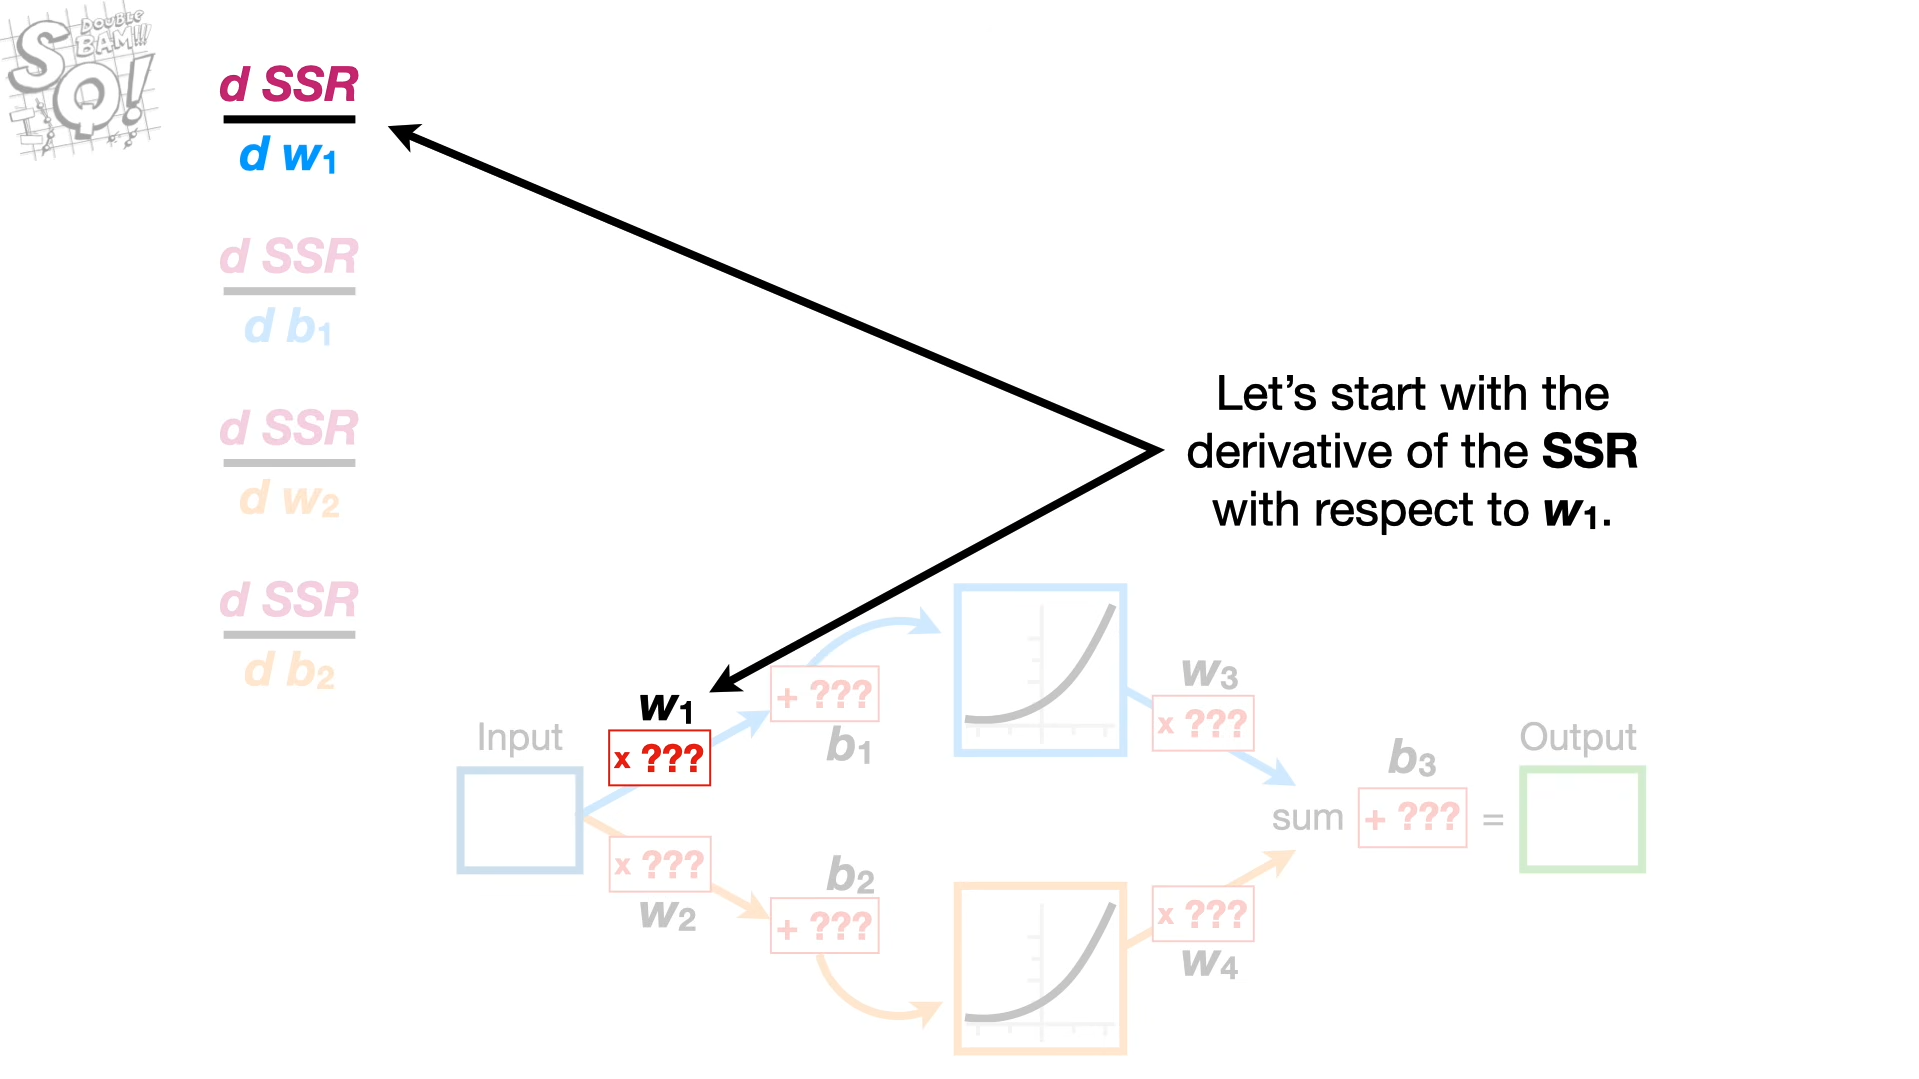
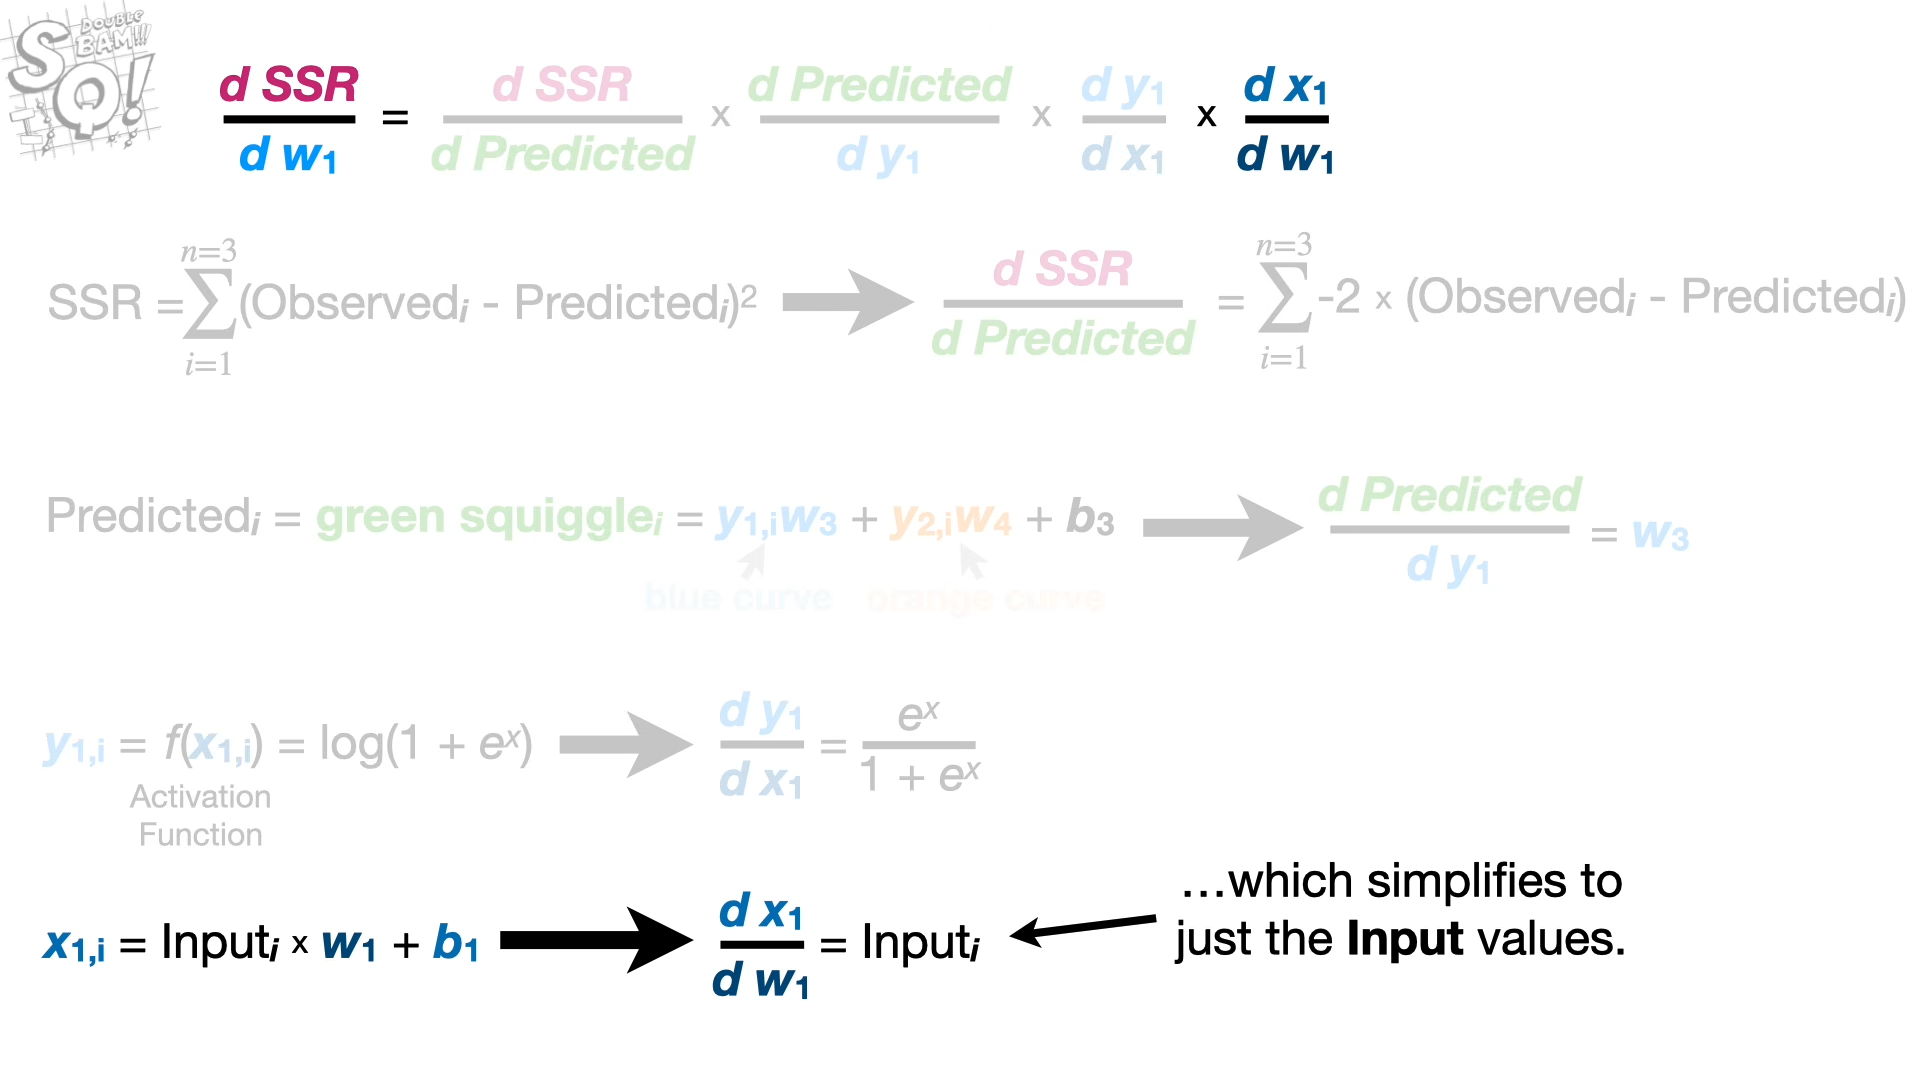
---

## 8. Khái niệm Vanishing và Exploding Gradient

Cơ chế nhân dồn đạo hàm sinh ra hai thảm họa toán học khi thiết kế các mạng nơ-ron rất sâu:

*   **Vanishing Gradient (Triệt tiêu đạo hàm):** Xảy ra khi các giá trị đạo hàm cục bộ tại mỗi lớp là một số nhỏ hơn $1$ (ví dụ: đạo hàm hàm Sigmoid luôn $\le 0.25$). Việc nhân liên tiếp các con số nhỏ hơn $1$ sẽ khiến Gradient tiến nhanh về $0$. Hệ quả là trọng số các lớp đầu không được cập nhật, mô hình ngừng học hoàn toàn.
*   **Exploding Gradient (Bùng nổ đạo hàm):** Xảy ra khi đạo hàm cục bộ có giá trị $> 1$. Qua chuỗi nhân, con số này phình to theo cấp số nhân và tiến tới vô cực (NaN). Hệ quả là các bước cập nhật hất văng mô hình khỏi quỹ đạo, làm sụp đổ quá trình huấn luyện.




Trong một mạng nơ-ron, mỗi nơ-ron thực hiện phép tính tuyến tính: $y = Wx + b$. Nếu chỉ sử dụng phép tính này, dù mạng có hàng trăm lớp (layers), về mặt toán học, toàn bộ mô hình cũng chỉ tương đương với một phép hồi quy tuyến tính (Linear Regression) đơn giản.

Hàm kích hoạt (Activation Function) được sinh ra để tạo ra **tính phi tuyến (non-linearity)**. Bằng cách "bẻ cong" các đường thẳng, nó cho phép mô hình AI học được những ranh giới phân loại phức tạp như nhận diện khuôn mặt, dịch thuật, hay lái xe tự động. Đồng thời, hàm kích hoạt hoạt động như một "người gác cổng", quyết định xem thông tin nào đủ quan trọng để truyền tiếp sang lớp nơ-ron phía sau.

---

## 9. Phân tích chi tiết 5 hàm kích hoạt thông dụng
Trong một mạng nơ-ron, mỗi nơ-ron thực hiện phép tính tuyến tính: $y = Wx + b$. Nếu chỉ sử dụng phép tính này, dù mạng có hàng trăm lớp (layers), về mặt toán học, toàn bộ mô hình cũng chỉ tương đương với một phép hồi quy tuyến tính (Linear Regression) đơn giản.

Hàm kích hoạt (Activation Function) được sinh ra để tạo ra **tính phi tuyến (non-linearity)**. Bằng cách "bẻ cong" các đường thẳng, nó cho phép mô hình AI học được những ranh giới phân loại phức tạp như nhận diện khuôn mặt, dịch thuật, hay lái xe tự động. Đồng thời, hàm kích hoạt hoạt động như một "người gác cổng", quyết định xem thông tin nào đủ quan trọng để truyền tiếp sang lớp nơ-ron phía sau.

---
### 9.1. Sigmoid (Logistic Function) - Máy ép xác suất
* **Công thức:** $\sigma(x) = \frac{1}{1 + e^{-x}}$
* **Bản chất:** Ép bất kỳ con số thực nào vào một khoảng hẹp từ $0$ đến $1$, tạo ra đường cong hình chữ S.
* **Khi nào dùng:** Chỉ dùng ở lớp đầu ra (Output Layer) cho bài toán Phân loại nhị phân (Binary Classification), ví dụ: "Ảnh này là chó hay mèo?", "Email này là spam hay không?".
* **Tại sao:** Khoảng giá trị từ $0$ đến $1$ của Sigmoid hoàn toàn khớp với định dạng của xác suất, vừa giúp con người dễ đọc hiểu, vừa là yêu cầu bắt buộc toán học cho hàm mất mát (như Binary Cross-Entropy) và các hệ thống tự động phía sau.
* **Tại sao KHÔNG dùng ở lớp ẩn:** Nhược điểm chí mạng là Vanishing Gradient (Triệt tiêu đạo hàm). Đạo hàm cực đại của Sigmoid chỉ là $0.25$. Khi nhân liên tiếp các số nhỏ hơn $1$ qua nhiều lớp, tín hiệu lỗi sẽ bốc hơi về $0$, khiến các lớp đầu tiên của mạng ngừng học.

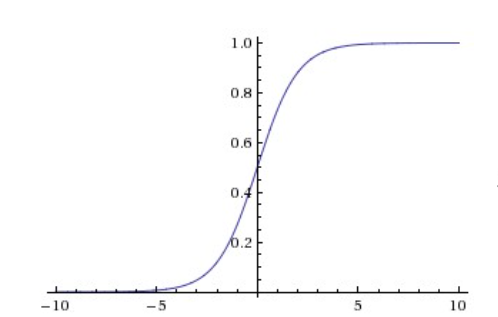
### 9.2. Tanh (Hyperbolic Tangent) - Công cụ cân bằng
* **Công thức:** $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
* **Bản chất:** Là phiên bản phóng to của Sigmoid, ép các giá trị vào khoảng từ $-1$ đến $1$.
* **Khi nào dùng:** Thường được sử dụng trong các lớp ẩn của mạng xử lý chuỗi thời gian, ngôn ngữ tự nhiên (RNN, LSTM).
* **Tại sao:** Nhờ dải giá trị từ $-1$ đến $1$, đồ thị của Tanh có tâm tại $0$ (zero-centered). Điều này giúp dữ liệu truyền qua các bước thời gian (time steps) trong RNN được cân bằng giữa âm và dương, giữ cho trạng thái ẩn ổn định, tránh hiện tượng dữ liệu bùng nổ (Exploding Gradient) đi sai hướng.


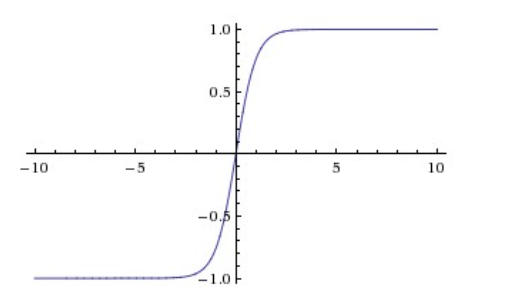
### 9.3. ReLU (Rectified Linear Unit) - Tiêu chuẩn công nghiệp
* **Công thức:** $f(x) = \max(0, x)$
* **Bản chất:** Giống như một câu lệnh if: Nếu đầu vào nhỏ hơn $0$, dập tắt thành $0$. Nếu đầu vào lớn hơn $0$, giữ nguyên.
* **Khi nào dùng:** Lựa chọn mặc định cho tất cả các lớp ẩn (Hidden Layers). Bất kể bạn đang xây dựng mạng MLP cơ bản hay CNN xử lý ảnh, hãy luôn thử ReLU đầu tiên.
* **Tại sao:**
  * **Tính toán siêu tốc:** So sánh với $0$ tốn chi phí tính toán cực thấp so với việc tính hàm mũ ($e^x$).
  * **Khắc phục Vanishing Gradient:** Ở vùng dương ($x > 0$), đạo hàm của ReLU luôn bằng $1$. Tín hiệu lỗi trong quá trình lan truyền ngược (Backpropagation) được giữ nguyên vẹn qua hàng trăm lớp mạng, giúp mô hình hội tụ nhanh chóng.
* **Nhược điểm:** Dying ReLU (Nơ-ron chết). Nếu một nơ-ron nhận đầu vào âm do thay đổi trọng số quá lớn (Learning rate cao), đầu ra sẽ bằng $0$, đạo hàm cũng bằng $0$. Nơ-ron này vĩnh viễn "đóng băng" và không thể học thêm được nữa.


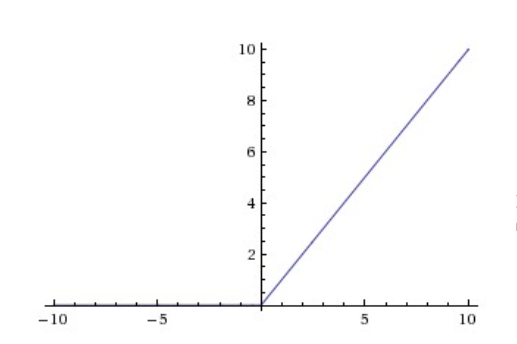
### 9.4. Leaky ReLU 
* **Công thức:** $f(x) = \max(\alpha x, x)$ (Trong đó $\alpha$ thường bằng $0.01$)
* **Bản chất:** Thay vì dập tắt số âm thành $0$ tròn trĩnh, nó cho phép một lượng tín hiệu cực nhỏ ("rò rỉ") đi qua vùng âm.
* **Khi nào dùng:** Chỉ dùng để thay thế ReLU ở các lớp ẩn khi bạn nhận thấy Loss function đứng im không giảm (dấu hiệu của việc quá nhiều nơ-ron bị chết).
* **Tại sao:** Bằng cách duy trì một độ dốc nhỏ (ví dụ $0.01$) ở phần âm, đạo hàm không bao giờ hoàn toàn bằng $0$. Các nơ-ron rơi vào vùng âm vẫn có cơ hội tự điều chỉnh trọng số nhích dần lên và "sống lại".

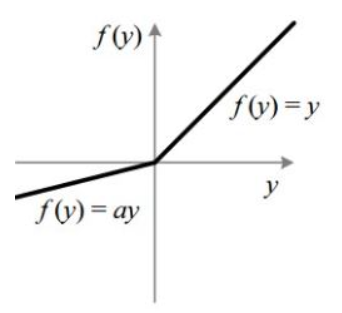
### 9.5. Softmax - Kẻ chia bánh phân số
* **Công thức:** $f(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{K} e^{x_j}}$
* **Bản chất:** Nhận vào một mảng điểm số thô và chuyển đổi chúng thành phân bố xác suất sao cho tổng tất cả các xác suất bằng đúng $1.0$ (hay 100%).
* **Khi nào dùng:** Chỉ dùng ở lớp đầu ra (Output Layer) cho các bài toán Phân loại nhiều lớp (Multi-class Classification) từ 3 nhóm trở lên (Ví dụ: Dự đoán ảnh thuộc loại Chó, Mèo, hay Chim).
* **Tại sao:** Chức năng lấy mũ ($e^x$) giúp khuếch đại mạnh mẽ sự chênh lệch (làm nổi bật lựa chọn tốt nhất và dìm các lựa chọn kém xuống sát $0$). Khi Softmax kết hợp cùng hàm mất mát Cross-Entropy, phép tính đạo hàm của chúng sẽ triệt tiêu các thành phần mẫu số phức tạp cho nhau, tạo ra một công thức cập nhật cực kỳ gọn gàng và hiệu quả.

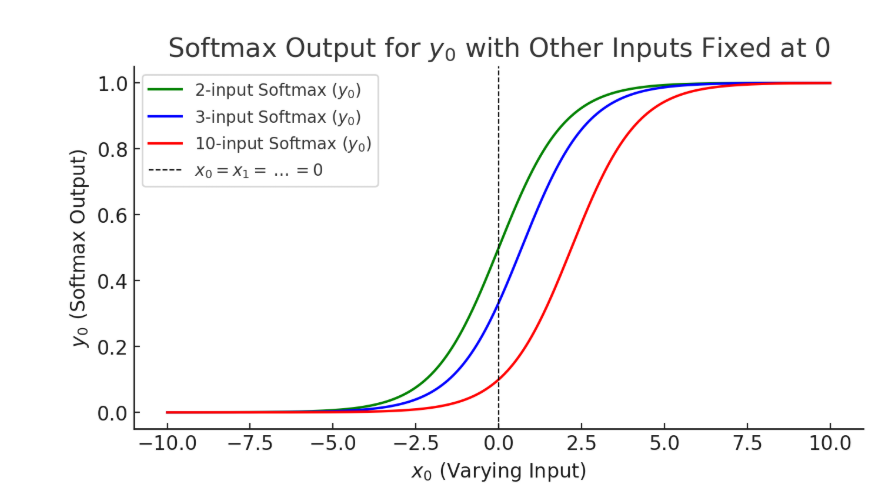
---

## 9.6. Tổng kết: Bảng Quyết định Thực chiến

| Tên Hàm | Vị trí khuyến nghị | Mục đích / Bài toán | Khoảng giá trị | Nhược điểm cần tránh |
| :--- | :--- | :--- | :--- | :--- |
| **Sigmoid** | Lớp đầu ra (Output) | Phân loại nhị phân (Binary Classification) | $(0, 1)$ | Vanishing Gradient |
| **Tanh** | Lớp ẩn (Hidden Layer) | Mạng xử lý chuỗi tuần tự (RNN, LSTM) | $(-1, 1)$ | Vanishing Gradient |
| **ReLU** | Lớp ẩn (Hidden Layer) | Mặc định cho hầu hết mọi mạng (MLP, CNN) | $[0, +\infty)$ | Dying ReLU (Nơ-ron chết) |
| **Leaky ReLU** | Lớp ẩn (Hidden Layer) | Dùng khi mạng dùng ReLU ngừng học | $(-\infty, +\infty)$ | Kết quả đôi khi không ổn định |
| **Softmax** | Lớp đầu ra (Output) | Phân loại nhiều lớp (Multi-class) | $(0, 1)$ (Tổng = 1) | Tính toán chi phí hàm mũ cao |



## 10. Loss Function
Hàm mất mát (Loss Function) là thành phần định hướng quá trình tối ưu hóa của toàn bộ mạng nơ-ron. Quyết định chọn hàm mất mát không chỉ phụ thuộc vào định dạng đầu ra của bài toán (số thực, nhãn phân loại, hay vector đặc trưng), mà còn ảnh hưởng trực tiếp đến tính ổn định của thuật toán Lan truyền ngược (Backpropagation), mức độ tiêu thụ bộ nhớ và tốc độ xử lý ma trận tính toán (Matrix Operations) ở tầng kỹ thuật cấp thấp.

---

## 10.1 Nhóm Bài Toán Hồi Quy (Regression)
Sử dụng khi mô hình cần dự đoán các giá trị số thực liên tục (ví dụ: tọa độ bounding box, giá trị pixel, dự báo nhiệt độ).

### 10.1.1. Mean Squared Error (MSE)
* **Công thức:** $$L_{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$
* **Khi nào dùng:** Mặc định cho mọi bài toán Hồi quy, nơi khoảng cách giữa dự đoán và thực tế có thể đo lường tuyến tính bằng các con số.
* **Tại sao lại dùng:**
  * **Đặc tính cốt lõi:** Sự xuất hiện của phép bình phương $(...)^2$ tạo ra đạo hàm bậc nhất là $2(\hat{y}_i - y_i)$.
  * **Trừng phạt dị biệt (Outliers):** Khi sai số lớn (ví dụ lệch 10 đơn vị), mức phạt sẽ tăng theo hàm mũ (100 đơn vị). Cường độ Gradient cực kỳ lớn, ép ma trận trọng số phải cập nhật một bước nhảy thật mạnh để sửa sai ngay lập tức.
  * **Hội tụ mượt mà (Smooth Convergence):** Khi dự đoán tiến sát đến giá trị thực, mức phạt tự động thu nhỏ về sát 0. Điều này giúp thuật toán dừng lại êm ái tại điểm đích, ngăn chặn hiện tượng dao động (oscillation).

---

## 10.2 Nhóm Bài Toán Phân Loại (Classification)
Mặc dù tại vị trí nhãn thực tế đúng ($y=1$), cả Binary Cross-Entropy (BCE) và Categorical Cross-Entropy (CCE) đều thu gọn về cùng một bản chất toán học là $-\log(p)$, việc phân tách rạch ròi hai hàm này là bắt buộc do sự khác biệt hoàn toàn về **cơ chế xử lý nhãn sai** và **ràng buộc không gian bài toán**.

### 10.2.1 Binary Cross-Entropy (BCE)
* **Công thức:** $$L_{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$
* **Khi nào dùng:** Phân loại nhị phân (0 hoặc 1) hoặc phân lớp đa nhãn độc lập (Multi-label). Luôn đặt sau hàm kích hoạt Sigmoid.
* **Tại sao lại dùng:**
  * **Không gian Độc lập (Multi-label):** Hệ thống không thiết lập giới hạn tổng tài nguyên. BCE coi mỗi nơ-ron đầu ra là một công tắc 2 trạng thái (Có/Không) độc lập. Tổng xác suất của toàn bộ các lớp hoàn toàn có thể vượt qua mốc 1.0 (ví dụ: mô hình có thể dự đoán 0.9 có chó và 0.85 có mèo trong cùng một ảnh). Các đặc trưng tồn tại song song mà không tranh giành xác suất của nhau.
  * **Trừng phạt chủ động (Cơ chế xử lý khi $y = 0$):** Phương trình BCE chứa thành phần đối xứng $-(1-y)\log(1-p)$. Khi gặp một nhãn sai ($y=0$), phần đầu triệt tiêu và phần đuôi được kích hoạt thành $-\log(1-p)$. Lúc này, BCE trực tiếp sinh ra một luồng Gradient độc lập để "đè bẹp" xác suất $p$ của nhãn sai đó về 0. Mạng nơ-ron phải tự tay xử lý thủ công từng nhãn sai một.
  * **Tối ưu Engine:** Khi ghép BCE với đạo hàm của Sigmoid, mẫu số của BCE sẽ triệt tiêu hoàn toàn tử số của Sigmoid. Kết quả trả về cho chuỗi Lan truyền ngược chỉ còn đúng một phép trừ $O(1)$: $\frac{\partial L}{\partial z} = \hat{y} - y$.

### 10.2.2 Categorical Cross-Entropy (CCE)
* **Công thức:** $$L_{CCE} = -\sum_{c=1}^{C} y_c \log(\hat{y}_c)$$
* **Khi nào dùng:** Phân loại đa lớp (Multi-class), nơi mỗi mẫu chỉ thuộc về duy nhất 1 lớp (nhãn One-hot, có tính loại trừ lẫn nhau). Luôn đi kèm hàm kích hoạt Softmax.
* **Tại sao lại dùng:**
  * **Không gian Cạnh tranh (Multi-class):** Hệ thống ép buộc các đặc trưng phải loại trừ lẫn nhau (Mutually Exclusive). Trong bài toán này, tổng không gian mẫu bị đóng băng ở mức 1.0. Việc CCE được kích hoạt đồng nghĩa với việc khởi động cơ chế cạnh tranh sinh tồn một-mất-một-còn, nơi sự gia tăng niềm tin vào một lớp bắt buộc phải đánh đổi bằng sự suy giảm niềm tin ở các lớp khác.
  * **Trừng phạt thụ động qua Softmax (Cơ chế xử lý khi $y = 0$):** Phương trình CCE không chứa thành phần đánh giá $y=0$, đồng nghĩa với việc nó hoàn toàn phớt lờ các nhãn sai. CCE dồn 100% công lực tính toán để tối đa hóa xác suất của duy nhất một nhãn đúng. Để dìm các nhãn sai, nó tận dụng đặc tính tĩnh của hàm Softmax. Do Softmax luôn ép tổng toàn bộ phân bố xác suất bằng 1.0, việc CCE đẩy xác suất nhãn đúng lên (ví dụ 0.99) sẽ tự động tạo ra một lực hút chân không, rút cạn toàn bộ quỹ xác suất của mọi nhãn sai còn lại (chia nhau 0.01).
  * **Tối ưu Engine:** Giống như BCE, đạo hàm gộp khối lượng tính toán của [Softmax + CCE] tự triệt tiêu các thành phần phức tạp ($e^x$ và $\log$), trả về ma trận gradient cực tối giản: $\frac{\partial L}{\partial z_i} = \hat{y}_i - y_i$.

---

### 10.2.3 Label Smoothing
* **Công thức biến đổi nhãn:** $$y_c^{LS} = (1 - \alpha) \cdot y_c + \frac{\alpha}{C}$$
* **Khi nào dùng:** Khi mạng có dấu hiệu học vẹt (Overfitting), mô hình lớn, hoặc chất lượng gán nhãn của tập Train không đáng tin cậy.
* **Tại sao lại dùng (Chặn bão hòa trọng số):** Để Softmax đạt được giá trị tuyệt đối 1.0 trên nhãn One-hot, các ma trận trọng số bị ép phải đẩy lên mức vô cực ($+\infty$). Label Smoothing thay đổi nhãn đích thành dạng mềm (ví dụ $[0.9, 0.05, 0.05]$). Khi dự đoán chạm tới 0.9, Gradient lập tức ngắt về 0, ép thuật toán dừng cập nhật sớm, duy trì trọng số ở dải an toàn và giữ lại mức Entropy giúp mô hình tổng quát hóa tốt hơn.

### 10.2.4 Focal Loss
* **Công thức:** $$L_{Focal} = -\sum_{c=1}^{C} \alpha_c (1 - \hat{y}_c)^\gamma y_c \log(\hat{y}_c)$$
* **Khi nào dùng:** Dữ liệu mất cân bằng cực độ (Extreme Class Imbalance), ví dụ: 1 triệu ảnh nền (dễ) và 100 ảnh có vật thể (khó).
* **Tại sao lại dùng (Điều biến Gradient):** 
  Vấn đề của hàm phân loại thông thường là dù mức phạt của mỗi mẫu dễ rất nhỏ, nhưng nếu cộng dồn hàng triệu mẫu lại thì nó sẽ tạo ra một lực Gradient khổng lồ đè bẹp nhóm mẫu khó. Mạng nơ-ron sẽ "học lười" bằng cách thiên vị đám đông đa số và phớt lờ nhóm thiểu số. 
  Để giải quyết, Focal Loss bổ sung **màng lọc tĩnh** $(1 - \hat{y}_c)^\gamma$ hoạt động như một bộ giảm âm. Giá trị của màng lọc này sẽ được nhân trực tiếp vào mức phạt ban đầu. Khi dự đoán một mẫu cực dễ (ví dụ $\hat{y}_c = 0.99$), hệ số này sẽ trở nên siêu nhỏ (như $(1 - 0.99)^2 = 0.0001$), qua đó ép giá trị Loss về sát 0.
* **Ví dụ trực quan (Bài toán nhận diện khối u X-quang):**
  Giả sử tập dữ liệu có 1.000.000 pixel Nền (Nhóm Dễ - mô hình tự tin đoán đúng 99%, $\hat{y}_c = 0.99$) và 100 pixel Khối u (Nhóm Khó - mô hình bối rối đoán 10%, $\hat{y}_c = 0.1$).
  * **Khi CHƯA dùng Focal Loss (Chỉ dùng Cross-Entropy thuần túy):**
    * *Nhóm Dễ:* Mức phạt mỗi pixel là 0.01. Tổng mức phạt của 1 triệu pixel nền là **10.000**.
    * *Nhóm Khó:* Mức phạt mỗi pixel là 2.3. Tổng mức phạt của 100 pixel khối u là **230**.
    * *Hệ quả:* Lực phạt của đám đông đè bẹp hoàn toàn nhóm thiểu số. Mô hình chọn cách "học lười", bỏ qua khối u và chỉ đoán nền để hạ nhanh tổng Loss.
  * **Khi CÓ dùng Focal Loss (Cài đặt $\gamma = 2$):**
    * *Nhóm Dễ:* Đi qua màng lọc $(1 - 0.99)^2 = 0.0001$. Tổng mức phạt của 1 triệu pixel nền bị bóp nghẹt, đánh tụt từ 10.000 xuống chỉ còn bằng **1**.
    * *Nhóm Khó:* Đi qua màng lọc $(1 - 0.1)^2 = 0.81$. Tổng mức phạt của 100 pixel khối u được giữ nguyên phần lớn, đạt mức **186**.
    * *Hệ quả:* Lực phạt từ nhóm thiểu số (186) đã áp đảo đám đông (1). Hệ thống tự động ngắt luồng cập nhật vô ích của hàng triệu mẫu dễ, dồn 100% tài nguyên CPU/GPU và Gradient để tối ưu hóa trọng số cho nhóm thiểu số.

---

## 10.3 Nhóm Biểu Diễn & Tương Đồng (Metric Learning)
Không phân loại cố định, biến mạng nơ-ron thành Bộ trích xuất đặc trưng hình học đa chiều.

### 10.3.1 Triplet Loss (Metric Learning)
* **Công thức:** $$L_{Triplet} = \max\Big( d(A, P) - d(A, N) + margin, 0 \Big)$$
* **Khi nào dùng:** Bài toán mở (Open-set) nơi nhãn thay đổi liên tục và không thể gán lớp cố định, ví dụ: Nhận diện khuôn mặt (FaceID), hệ thống tìm kiếm hình ảnh tương đồng, hoặc xác thực chữ ký.
* **Vì sao lại dùng:**
  * Khắc phục điểm yếu chí mạng của bài toán Phân loại thông thường (Classification) vốn bắt mạng nơ-ron "học thuộc lòng" số lượng lớp cố định. Nếu có thêm một đối tượng mới, phân loại thông thường buộc phải huấn luyện lại từ đầu, trong khi phương pháp này không cần làm vậy.
  * Có khả năng **từ chối người lạ (Rejecting Unknowns)** cực kỳ mạnh mẽ dựa trên khoảng cách tuyệt đối so với ngưỡng an toàn (`margin`). Tránh được thảm họa nhận diện nhầm của hàm Softmax khi đối mặt với dữ liệu hoàn toàn mới chưa từng xuất hiện trong tập huấn luyện.
* **Nó hoạt động trong mạng nơ-ron như thế nào:**
  * **Đầu vào "Sinh ba" (Triplet Input):** Trong mỗi vòng lặp, hệ thống bốc đồng thời 3 ảnh đưa vào mạng gồm ảnh **A** (Anchor - mẫu gốc), ảnh **P** (Positive - mẫu cùng loại chụp góc khác), và ảnh **N** (Negative - mẫu khác loại).
  * **Đi qua Bộ trích xuất (Backbone) - Dùng chung trọng số:** Cả 3 bức ảnh được đưa qua cùng một mạng nơ-ron (như ResNet, CNN) đã được "chặt bỏ" lớp Softmax ở cuối. Lớp cuối cùng (thường là Linear Layer kết hợp L2 Normalization) sẽ ép mỗi ảnh thành một mảng số thực (Vector Embedding), nhả ra 3 vector tương ứng là $V_A$, $V_P$, và $V_N$.
  * **Tính toán khoảng cách:** Hàm Triplet Loss nhận 3 vector này và thực hiện phép đo hình học (dùng khoảng cách Euclidean hoặc Cosine) để đo $d(A, P)$ và $d(A, N)$, từ đó kiểm tra xem $N$ đã văng ra xa khỏi $A$ vượt qua khoảng an toàn (`margin`) so với $P$ hay chưa.
  * **Lan truyền ngược (Backpropagation):** Nếu $d(A, P)$ còn quá xa hoặc $d(A, N)$ còn quá gần, hệ thống tạo ra giá trị Loss lớn. Luồng Gradient chạy ngược về mạng nơ-ron để cập nhật ma trận trọng số, giúp mô hình tự điều chỉnh học các đặc trưng cốt lõi (như khoảng cách hai mắt, độ gồ xương gò má) thay vì học thuộc màu áo hay phông nền.


### 10.3.2 InfoNCE (Contrastive Loss)
* **Công thức:** $$L_{InfoNCE} = -\log \frac{\exp(q \cdot k_+ / \tau)}{\sum_{i=0}^{K} \exp(q \cdot k_i / \tau)}$$
* **Khi nào dùng:** Học tự giám sát (Self-supervised Learning) như mô hình CLIP (OpenAI), SimCLR (Google), hoặc hệ thống tìm kiếm Vector (Vector Search) tỷ mẫu.
* **Vì sao lại dùng:**
  * **Giải quyết sự sụp đổ mô hình (Model Collapse):** Thay vì phân loại nhãn cố định, hệ thống ép AI khám phá đặc trưng bằng cách tìm ra 1 bản gốc (Positive) giữa hàng ngàn kẻ giả mạo (Negatives). Hàng ngàn ảnh sai này tạo ra "lực đẩy", ép AI buộc phải phân tích tỉ mỉ sự khác biệt độc bản của vật thể để không bị phạt.
  * **Giải phóng "Cổ chai" phần cứng:** Khắc phục điểm yếu tổ hợp 3 chiều ($O(N^3)$) gây tràn RAM và bắt buộc phải lọc dữ liệu thủ công của Triplet Loss. InfoNCE nén toàn bộ bài toán đối chiếu khổng lồ vào phép tính ma trận 2 chiều, tận dụng hoàn hảo sức mạnh tính toán song song của GPU.
* **Nó hoạt động trong mạng nơ-ron như thế nào:**
  * **Đầu vào "Phân thân" (Data Augmentation):** Máy tính bốc một lô (Batch) gồm $N$ bức ảnh ngẫu nhiên, tạo ra 2 bản sao bị bóp méo (khối Query $Q$ và khối Key $K$). Lúc này, ảnh $Q_1$ và $K_1$ là cặp đáp án đúng (Positive), trong khi các ảnh còn lại trong lô tự động trở thành mẫu sai (Negative).
  * **Đi qua Bộ trích xuất (Backbone) - Nén ngữ nghĩa:** Cả 2 khối ảnh được đẩy ồ ạt qua mạng nơ-ron (như ResNet, ViT). Ma trận trọng số $W$ và độ lệch $b$ quét qua toàn bộ dữ liệu để vứt bỏ thông tin rác, ép chúng thành các Vector đặc trưng tinh gọn (nhả ra 2 ma trận $Z_Q$ và $Z_K$).
  * **Tính toán khoảng cách (Đấu trường Ma trận):** Dùng lệnh nhân ma trận tích vô hướng ($Z_Q \cdot Z_K^T$). GPU sử dụng hàng chục ngàn lõi Tensor Cores để tính toán đồng loạt, sinh ra một Bảng điểm khổng lồ chứa hàng triệu kết quả đối chiếu chéo chỉ trong một nhịp tính toán duy nhất.
  * **Lan truyền ngược (Backpropagation):** Hệ thống chia bảng điểm cho hệ số nhiệt độ $\tau$ để phóng đại sự khác biệt, sau đó dùng hàm `Softmax` ép xác suất đáp án đúng về $1.0$ và đáp án sai về $0$. Giá trị Loss được sinh ra sẽ tạo luồng Gradient chạy ngược về mạng nơ-ron để vặn chỉnh lại ma trận trọng số, giúp mô hình tự động kéo ảnh giống nhau lại gần và đẩy ảnh khác nhau ra xa.